In [56]:
import pandas as pd
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import random
import warnings
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [104]:
# Load the GeoPackage
city = 'ACC'
grd_sz = 200
tiles_path = f'{city}/{city}_LCZ_morph_km_sicCAR_200m_dup.gpkg'
tiles = gpd.read_file(tiles_path)
tiles = tiles[tiles['LCZ']<10]

In [105]:
tiles.columns

Index(['PARTIMAP_I', 'LCZ', 'stcOri', 'sdcLAL', 'sdcAre', 'sscCCo', 'sscERI',
       'mtcWNe', 'mdcAre', 'sicCAR', 'ssbCCM', 'ssbCCD', 'mtbAli', 'mtbNDi',
       'ltbIBD', 'ltcBuA', 'cluster', 'mean_ndvi', 'max_ndvi', 'mean_ndwi',
       'canopy_area', 'geometry'],
      dtype='object')

In [106]:
print(tiles['LCZ'].unique())
print(tiles['cluster'].unique())

[3 6 8 9]
[0 1 2 3 4 5 6 7]


In [109]:
# Calculate counts
counts = tiles.groupby(['LCZ', 'cluster']).size().unstack(fill_value=0)

# Calculate percentages
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Define custom colors, hatching, and alpha (opacity) for each cluster
cluster_colors = {
    0: '#FE0000',
    1: '#FF0000',
    2: '#FF9856',
    3: '#FF9856',
    4: '#BCBCBC',
    5: '#BCBCBC',
    6: '#FECCA9',
    7: '#FECCA9',
    8: '#FECCA9',
    9: '#FECCA9'
}

cluster_hatch = {
    1: '//',
    3: '//',
    5: '//',
    7: '//',
    9: '//'
}

cluster_alpha = {
    1: 0.4,
    3: 0.4,
    5: 0.4,
    7: 0.4,
    9: 0.4
}
lcz_labels = {
    3: 'Compact lowrise',
    6: 'Open lowrise',
    8: 'Large lowrise',
    9: 'Sparsely built'
}

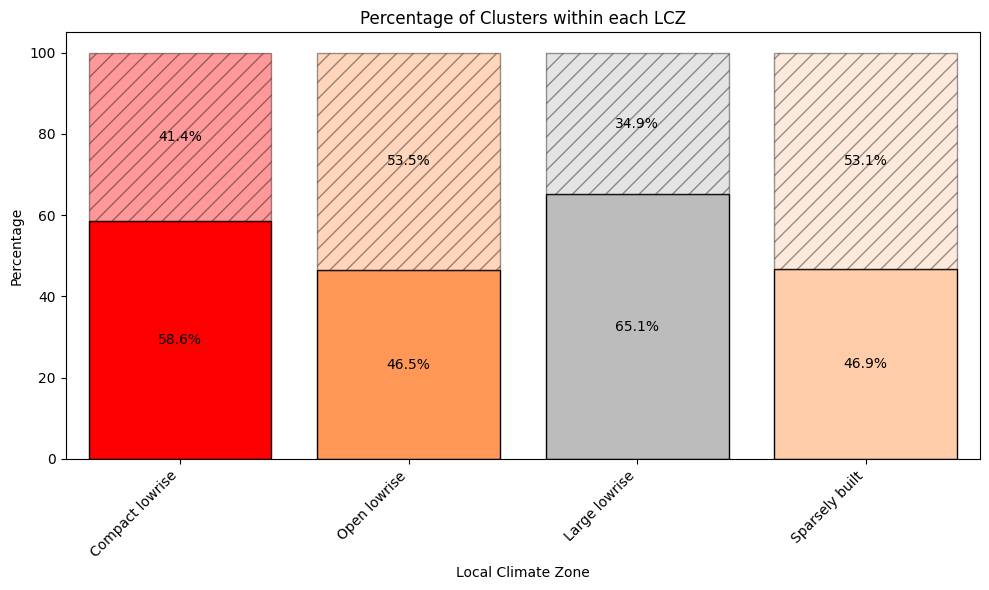

In [143]:
# Plotting with custom colors
ax = percentages.plot(kind='bar', stacked=True, figsize=(10, 6), color=[cluster_colors[col] for col in percentages.columns], alpha=0, legend=False)

plt.xlabel("Local Climate Zones")
plt.ylabel("Percentage")
plt.title("Percentage of Clusters within each LCZ")
new_labels = [lcz_labels.get(lcz, str(lcz)) for lcz in percentages.index]
plt.xticks(range(len(percentages.index)), new_labels, rotation=45, ha='right')

# Apply hatching and alpha to specific clusters
for i, lcz in enumerate(percentages.index):
    bottom = 0
    # Process clusters in reverse order for 4 and 5
    clusters = list(percentages.columns)
    for cluster, percentage in percentages.loc[lcz].items():
        if percentage > 0:
            rect = patches.Rectangle((i - 0.4, bottom), 0.8, percentage,
                                     linewidth=1, edgecolor='black', facecolor=cluster_colors[cluster],
                                     hatch=cluster_hatch.get(cluster, None),
                                     alpha=cluster_alpha.get(cluster, 1.0))
            ax.add_patch(rect)
        bottom += percentage

# Add percentage labels
for i, lcz in enumerate(percentages.index):
    bottom = 0
    for cluster, percentage in percentages.loc[lcz].items():
        if percentage > 0:
            ax.text(i, bottom + percentage / 2, f"{percentage:.1f}%",
                    ha='center', va='center', color='black')
        bottom += percentage

plt.tight_layout()
# plt.savefig('figs/ACC_LCZ_cluster_distribution.jpg', format='jpg', dpi=300)
plt.show()

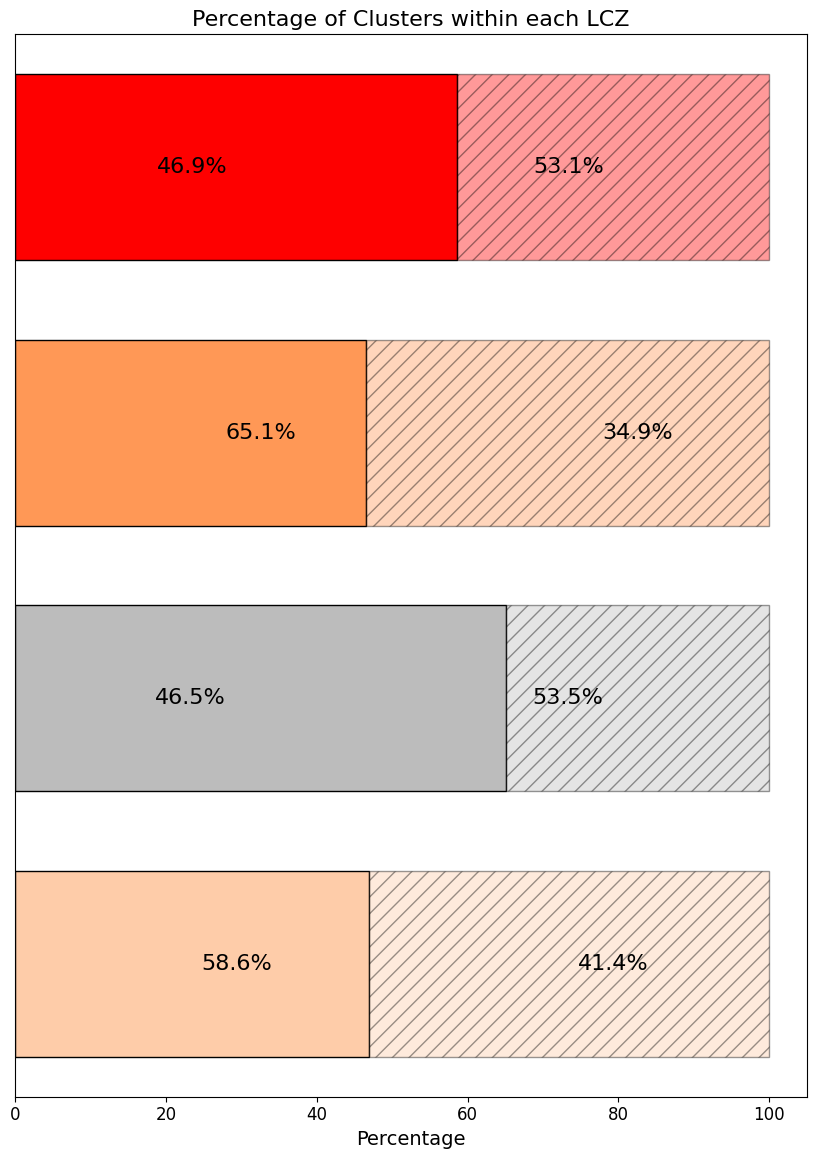

In [161]:
# Plotting with custom colors (horizontal bar graph)
ax = percentages.plot(kind='barh', stacked=True, figsize=(8.27, 11.69), color=[cluster_colors[col] for col in percentages.columns], alpha=0, legend=False)

plt.xlabel("Percentage", fontsize=14)  # Increase x-axis label font size
plt.title("Percentage of Clusters within each LCZ", fontsize=16)  # Increase title font size
plt.ylabel(None)
plt.yticks([])  # Remove y-axis ticks and labels
ax.tick_params(axis='x', labelsize=12)
# Apply custom labels for LCZ
# new_labels = [lcz_labels.get(lcz, str(lcz)) for lcz in percentages.index]
# plt.yticks(range(len(percentages.index)), new_labels)

# Apply hatching and alpha to specific clusters
for i, lcz in reversed(list(enumerate(percentages.index))):
    left = 0  # Start from the left edge of the bar
    for cluster, percentage in percentages.loc[lcz].items():
        if percentage > 0:
            # Draw horizontal rectangles
            rect = patches.Rectangle((left, len(percentages)-1-i - 0.35), percentage, 0.7,
                                     linewidth=1, edgecolor='black', facecolor=cluster_colors[cluster],
                                     hatch=cluster_hatch.get(cluster, None),
                                     alpha=cluster_alpha.get(cluster, 1.0))
            ax.add_patch(rect)
        left += percentage  # Move the starting position for the next cluster

# Add percentage labels
for i, lcz in enumerate(percentages.index):
    left = 0
    for cluster, percentage in percentages.loc[lcz].items():
        if percentage > 0:
            ax.text(left + percentage / 2, i, f"{percentage:.1f}%",
                    ha='center', va='center', color='black', fontsize=16)
        left += percentage

plt.tight_layout()
plt.savefig('figs/ACC_LCZ_cluster_distribution_horizontal.jpg', format='jpg', dpi=300)
plt.show()

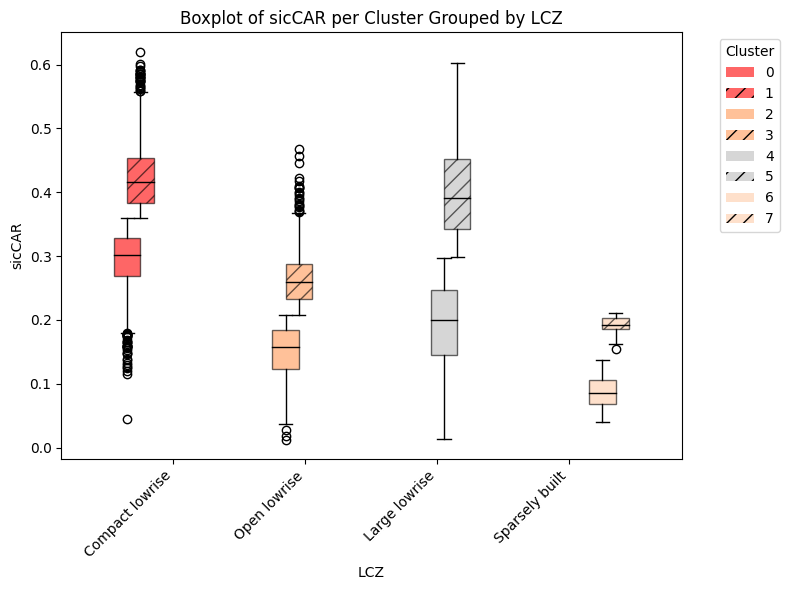

In [137]:
# Group the data by LCZ and cluster
grouped = tiles.groupby(['LCZ', 'cluster'])['sicCAR'].apply(list).reset_index()

# Get unique LCZs and clusters
lczs = sorted(tiles['LCZ'].unique())  # Sort LCZs explicitly
clusters = sorted(tiles['cluster'].unique())  # Sort clusters explicitly

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Define positions for the boxplots
bar_width = 0.8 / len(clusters)
positions = np.arange(len(lczs))

# Plot boxplots for each cluster within each LCZ
for i, cluster in enumerate(clusters):
    data = []
    for lcz in lczs:
        # Filter data for the current LCZ and cluster
        filtered_data = grouped[(grouped['LCZ'] == lcz) & (grouped['cluster'] == cluster)]['sicCAR']
        # If data exists, use it; otherwise, use an empty list
        if not filtered_data.empty:
            data.append(filtered_data.values[0])
        else:
            data.append([])  # Empty list for missing data
    # Calculate the position for the current cluster within the LCZ group
    cluster_positions = positions + (i - (len(clusters) - 1) / 2) * bar_width
    # Plot the boxplot with wider boxes
    box = ax.boxplot(data, positions=cluster_positions, widths=2 * bar_width,  # Adjust width here
                     patch_artist=True,
                     boxprops=dict(facecolor=cluster_colors[cluster], alpha=0.6, hatch=cluster_hatch.get(cluster, None)),
                     medianprops=dict(color='black'))

# Customize the plot
ax.set_xlabel("LCZ")
ax.set_ylabel("sicCAR")
ax.set_title("Boxplot of sicCAR per Cluster Grouped by LCZ")
ax.set_xticks(positions)
custom_labels = [lcz_labels.get(lcz, str(lcz)) for lcz in lczs]
ax.set_xticklabels(custom_labels, rotation=45, ha='right')

# Add a legend
handles = [patches.Patch(facecolor=cluster_colors[cluster], hatch=cluster_hatch.get(cluster, None),
                         alpha=0.6, label=cluster) for cluster in clusters]
ax.legend(handles=handles, title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

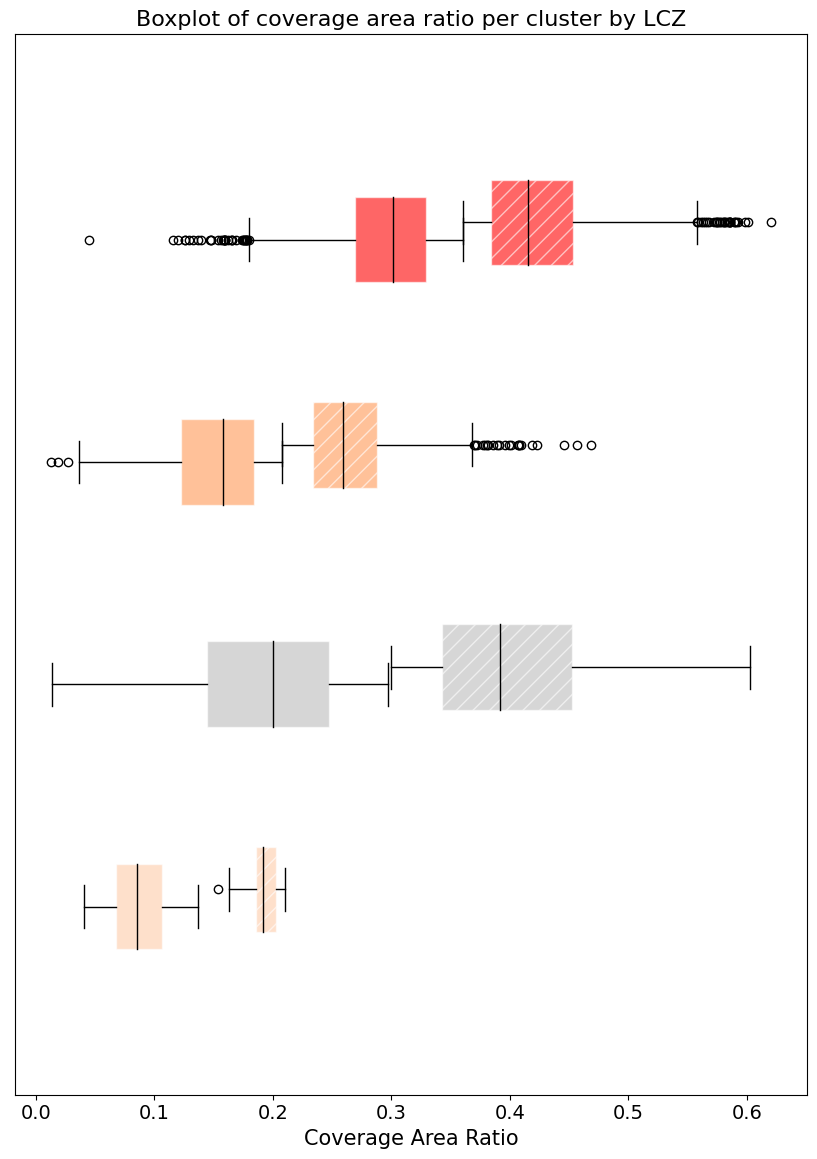

In [180]:
# Group the data by LCZ and cluster
grouped = tiles.groupby(['LCZ', 'cluster'])['sicCAR'].apply(list).reset_index()

# Get unique LCZs and clusters
lczs = sorted(tiles['LCZ'].unique(), reverse=True)  # Sort LCZs explicitly
clusters = sorted(tiles['cluster'].unique())  # Sort clusters explicitly

# Set up the plot
fig, ax = plt.subplots(figsize=(8.27, 11.69))

# Define positions for the boxplots
bar_width = 0.8 / len(clusters)
spacing = 1.5
positions = np.arange(len(lczs))*spacing

# Plot boxplots for each cluster within each LCZ
for i, cluster in enumerate(clusters):
    data = []
    for lcz in lczs:
        # Filter data for the current LCZ and cluster
        filtered_data = grouped[(grouped['LCZ'] == lcz) & (grouped['cluster'] == cluster)]['sicCAR']
        # If data exists, use it; otherwise, use an empty list
        if not filtered_data.empty:
            data.append(filtered_data.values[0])
        else:
            data.append([])  # Empty list for missing data
    # Calculate the position for the current cluster within the LCZ group
    cluster_positions = positions + (i - (len(clusters) - 1) / 1) * bar_width
    # Plot the boxplot with wider boxes and horizontal orientation
    box = ax.boxplot(data, positions=cluster_positions, widths=5 * bar_width, vert=False,  # Set vert=False for horizontal orientation
                     patch_artist=True,
                     boxprops=dict(facecolor=cluster_colors[cluster], alpha=0.6, hatch=cluster_hatch.get(cluster, None), edgecolor='white'),
                     medianprops=dict(color='black'))

plt.xlabel("Coverage Area Ratio", fontsize=15)  # Increase x-axis label font size
plt.title("Boxplot of coverage area ratio per cluster by LCZ", fontsize=16)
plt.ylabel(None)
plt.yticks([])  # Remove y-axis ticks and labels
ax.tick_params(axis='x', labelsize=14)

plt.tight_layout()
plt.savefig('figs/ACC_LCZ_cluster_sicCAR_boxplot.jpg', format='jpg', dpi=300)
plt.show()